In [287]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


## 1. Import Libraries

In [288]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load Dataset

In [289]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Data Understanding

In [290]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [291]:
print("Statistical Summary")
df.describe().round(2)

Statistical Summary


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 4. Features:
1. country
2. child_mort
3. exports
4. health
5. imports
6. income
7. inflation
8. life_expec
9. total_fer
10. gdpp

Cleaning DATA

In [292]:

print("Missing Values",df.isnull().sum())
print("\n")
print("Duplicates : ",df.duplicated().sum())

Missing Values country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Duplicates :  0


 ## 5. Exploratory Data Analysis 

Feature Distribution


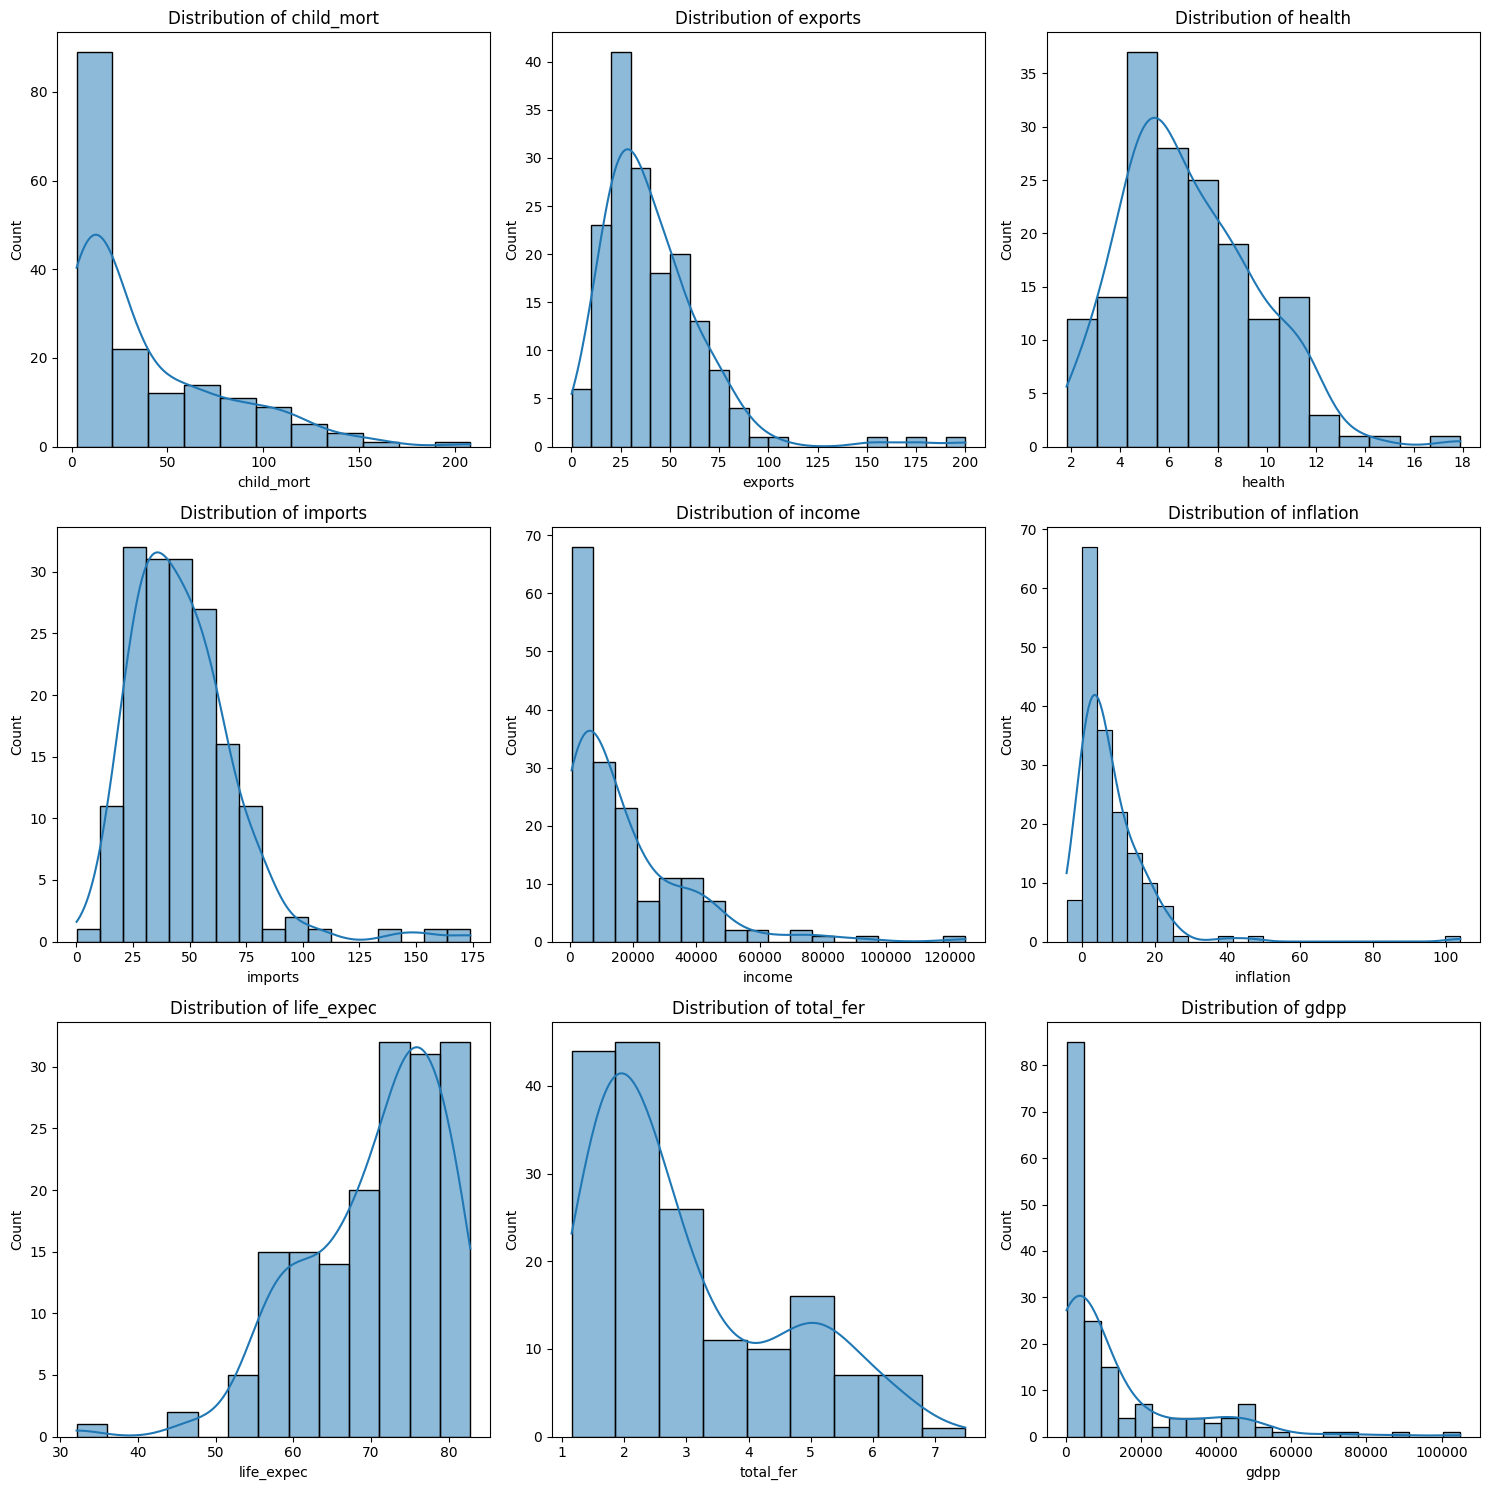

In [293]:
print("Feature Distribution")
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:10]):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


Outlier Analysis


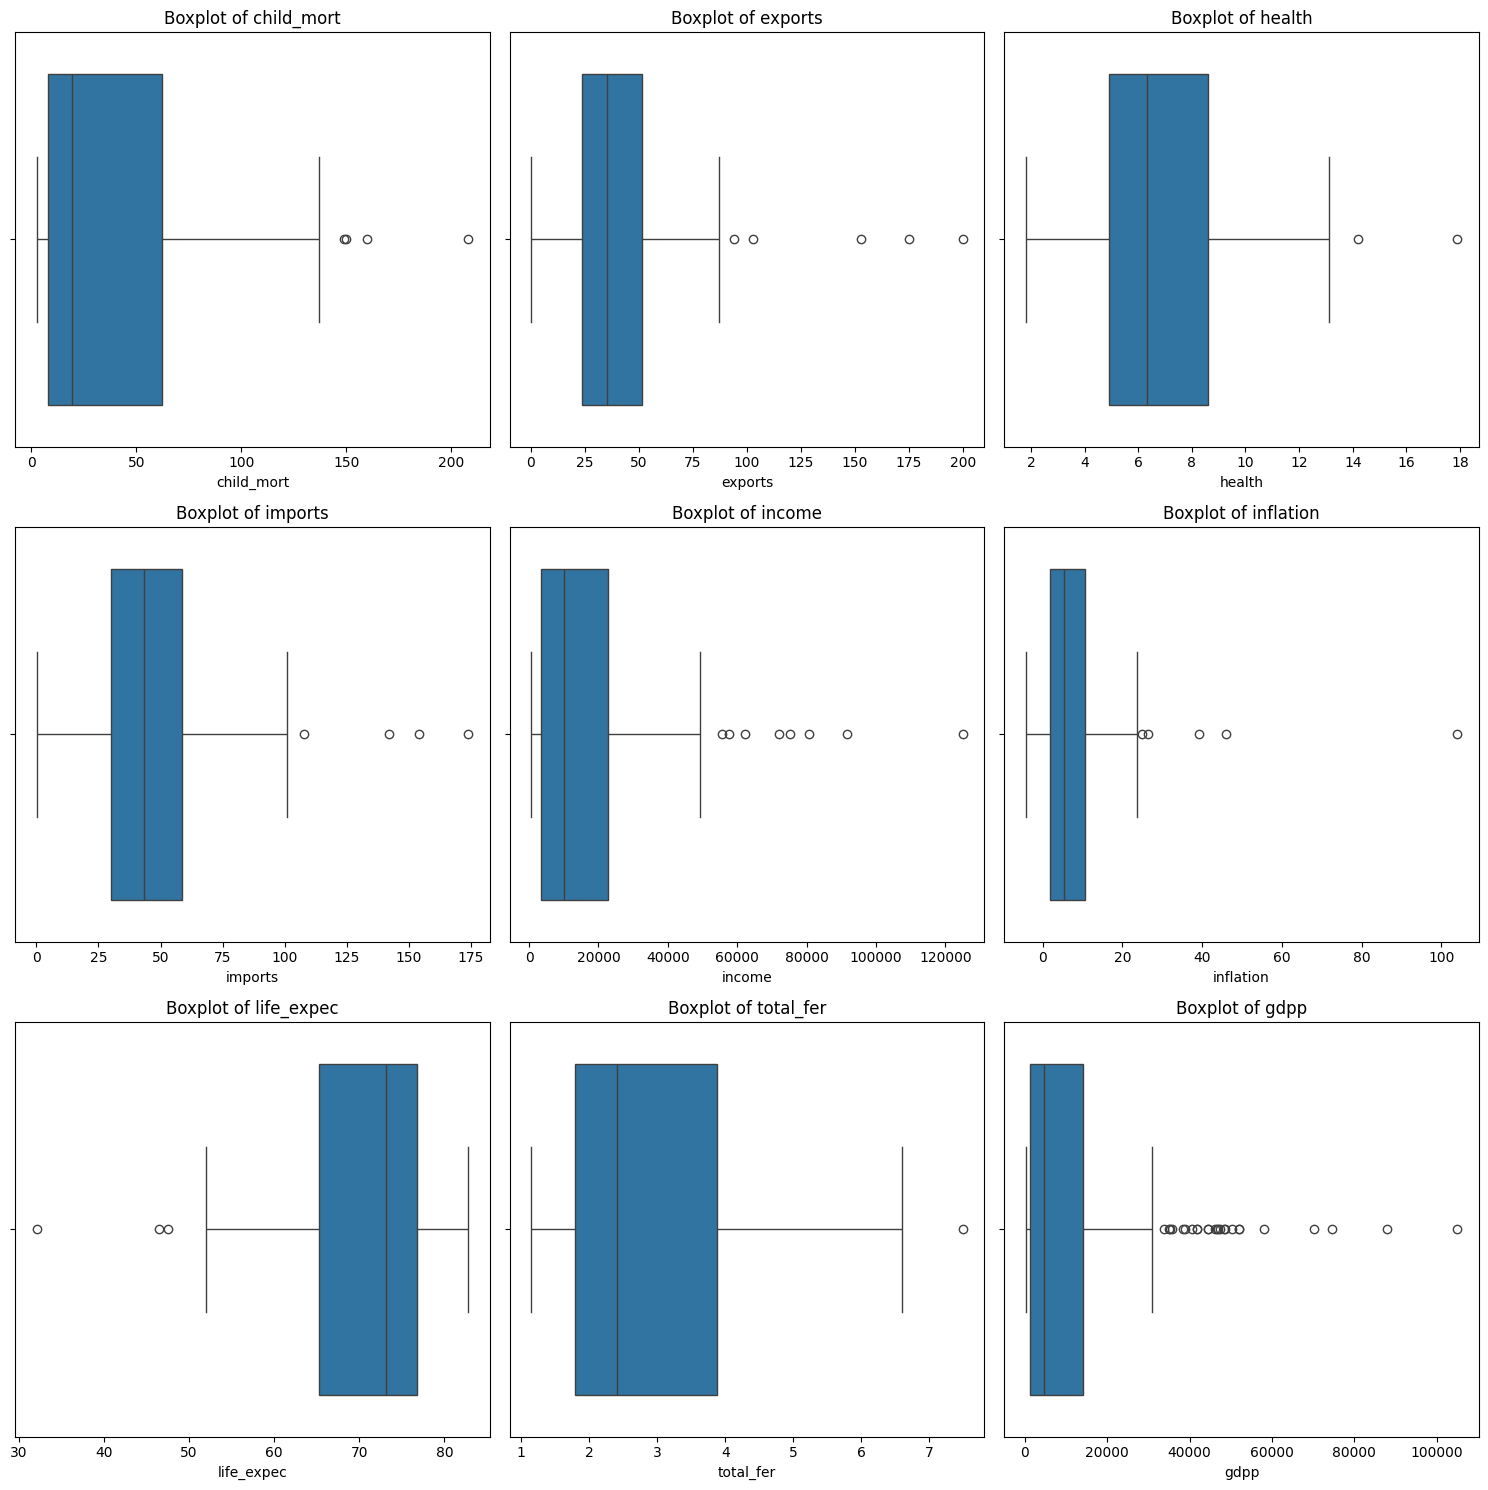

In [294]:
print("Outlier Analysis")
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:10]):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


In [295]:
print("Correlation analysis ")
corr_matrix = df.drop(columns=['country'],errors='ignore').corr()
corr_matrix.round(2)

Correlation analysis 


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.00,-0.32,-0.20,-0.13,-0.52,0.29,-0.89,0.85,-0.48
exports,-0.32,1.00,-0.11,0.74,0.52,-0.11,0.32,-0.32,0.42
health,-0.20,-0.11,1.00,0.10,0.13,-0.26,0.21,-0.20,0.35
imports,-0.13,0.74,0.10,1.00,0.12,-0.25,0.05,-0.16,0.12
income,-0.52,0.52,0.13,0.12,1.00,-0.15,0.61,-0.50,0.90
inflation,0.29,-0.11,-0.26,-0.25,-0.15,1.00,-0.24,0.32,-0.22
life_expec,-0.89,0.32,0.21,0.05,0.61,-0.24,1.00,-0.76,0.60
total_fer,0.85,-0.32,-0.20,-0.16,-0.50,0.32,-0.76,1.00,-0.45
gdpp,-0.48,0.42,0.35,0.12,0.90,-0.22,0.60,-0.45,1.00


Heatmap


<Axes: >

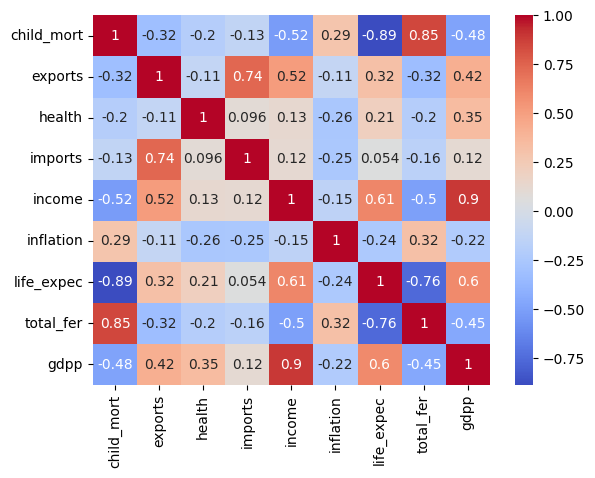

In [296]:
print("Heatmap")
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

### Correlation Analysis

From the correlation plot, a number of strong correlations between socio-economic parameters are found.

Main findings:

- Income and GDP per capita exhibit a strong positive correlation.
- Higher income and GDP lead to an increase in life expectancy.
- Child mortality has a strong negative correlation with income, GDP, and life expectancy.
- A number of variables include redundant information, suggesting that multicollinearity exists.

For this reason, PCA was used to decrease dimensionality while retaining most information from the initial parameters.

## 6. Feature Scaling

In [297]:
from sklearn.preprocessing import StandardScaler

features = df.drop('country', axis=1)

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [298]:
scaled_df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


## 7. PCA

In [299]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_df)

PCA()

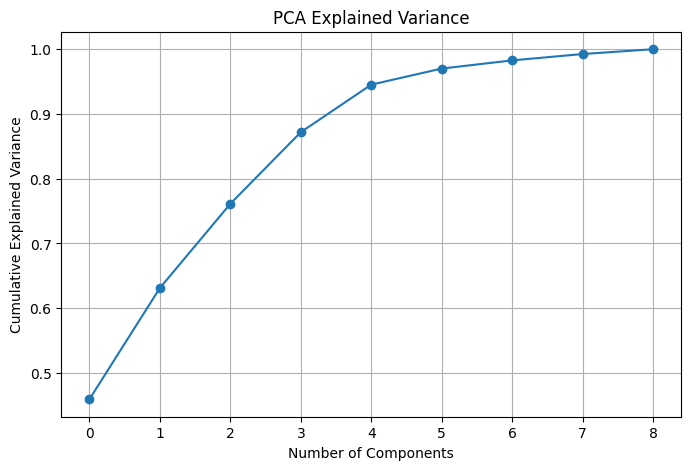

In [300]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_),marker='o')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)

plt.show()

In [301]:
pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_df)
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.4595174  0.17181626 0.13004259 0.11053162 0.07340211]

Total Variance Retained:
0.9453099756439515


In [302]:
print("DataFrame Creation ")
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
pca_df.head()

DataFrame Creation 


,PC1,PC2,PC3,PC4,PC5
0,-2.913025,0.095621,-0.718118,1.005255,-0.158310
1,0.429911,-0.588156,-0.333486,-1.161059,0.174677
2,-0.285225,-0.455174,1.221505,-0.868115,0.156475
3,-2.932423,1.695555,1.525044,0.839625,-0.273209
4,1.033576,0.136659,-0.225721,-0.847063,-0.193007


PCA Visualization


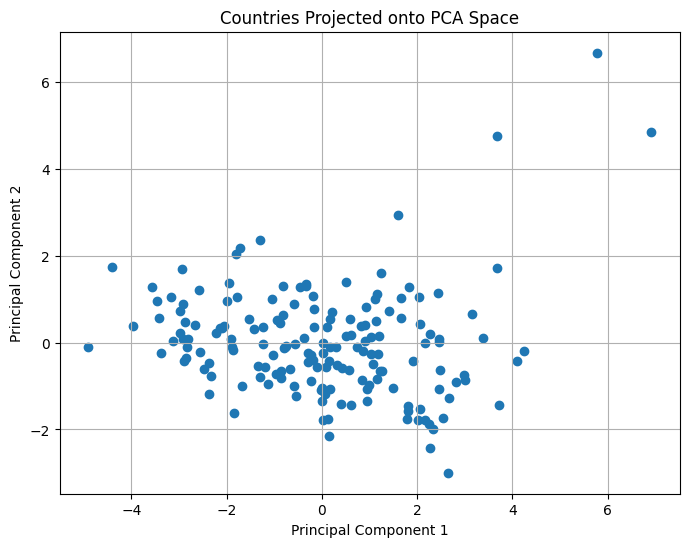

In [303]:
print("PCA Visualization")
plt.figure(figsize=(8,6))

plt.scatter(pca_df['PC1'],pca_df['PC2'])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Countries Projected onto PCA Space')

plt.grid(True)

plt.show()

**PCA Analysis**

The original dataset contains multiple correlated socio-economic indicators.
PCA was applied to reduce dimensionality while retaining the majority of information.
Results:
- 5 principal components were retained.
- Total variance retained = 94.53%.

This means that only a small amount of information was lost while significantly reducing feature redundancy.

## 8. K-Means: Elbow method

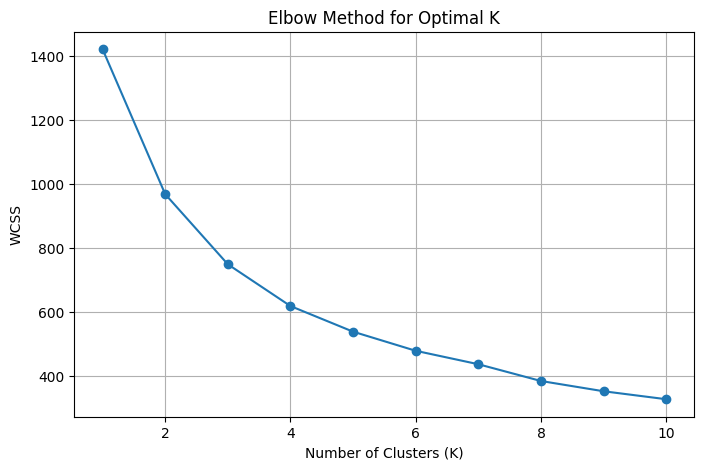

In [304]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)

plt.show()

## 8.2 Silhouette Score

K=2 --> Silhouette Score=0.3044
K=3 --> Silhouette Score=0.3080
K=4 --> Silhouette Score=0.3287
K=5 --> Silhouette Score=0.3305
K=6 --> Silhouette Score=0.2560
K=7 --> Silhouette Score=0.2262
K=8 --> Silhouette Score=0.2582
K=9 --> Silhouette Score=0.2364
K=10 --> Silhouette Score=0.2452


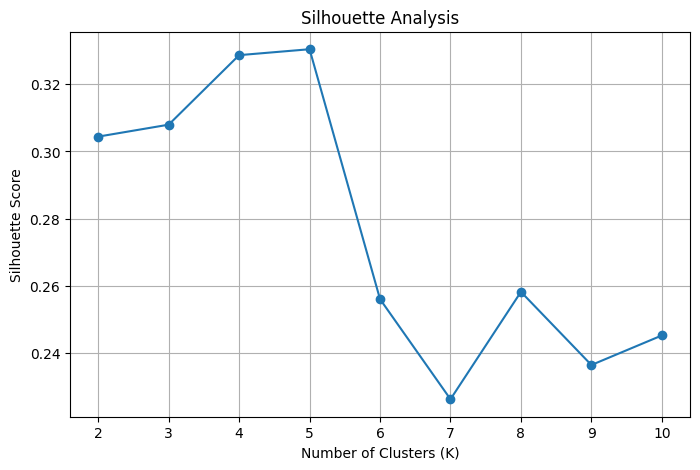

In [305]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(pca_df)
    score = silhouette_score( pca_df,labels)
    silhouette_scores.append(score)
    print(f"K={k} --> Silhouette Score={score:.4f}")
    
plt.figure(figsize=(8,5))

plt.plot(range(2,11),silhouette_scores,marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.grid(True)
plt.show()

## 9. K- MEANS CLUSTER

In [306]:
print("Training K-Means")
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df['KMeans_Cluster'] = kmeans.fit_predict(pca_df)
print(df['KMeans_Cluster'].value_counts())

Training K-Means
KMeans_Cluster
0    89
2    45
1    30
3     3
Name: count, dtype: int64


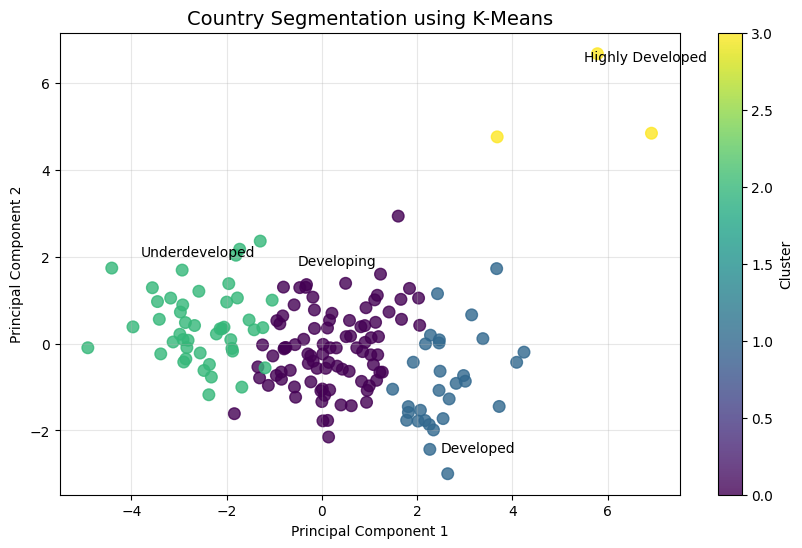

In [307]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=70,
    alpha=0.8
)


plt.title('Country Segmentation using K-Means', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.text(5.5, 6.5, 'Highly Developed', fontsize=10)
plt.text(2.5, -2.5, 'Developed', fontsize=10)
plt.text(-3.8, 2.0, 'Underdeveloped', fontsize=10)
plt.text(-0.5, 1.8, 'Developing', fontsize=10)

cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

plt.grid(alpha=0.3)

plt.show()

**K-Means Analysis**

The Elbow Method and Silhouette Analysis were used to determine the optimal number of clusters.

K = 4 was selected because it provided a balance between cluster separation and business interpretability.

The resulting clusters represent different levels of country development ranging from highly developed nations to countries requiring urgent humanitarian assistance.

In [308]:
cluster_profile = (df.groupby('KMeans_Cluster').mean(numeric_only=True))
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,21.913483,41.295382,6.283483,47.918718,12969.325843,7.533607,72.693258,2.318764,6885.528090
1,4.953333,45.826667,9.168667,39.736667,45250.000000,2.742200,80.376667,1.795333,43333.333333
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


## 10. DBSCAN

In [309]:
print("Parameter Tuning")
for eps in [0.5, 0.7, 0.9, 1.1,1.3]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(scaled_df)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"eps={eps}, clusters={n_clusters}")

Parameter Tuning
eps=0.5, clusters=0
eps=0.7, clusters=1
eps=0.9, clusters=3
eps=1.1, clusters=4
eps=1.3, clusters=2


In [310]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.35,
    min_samples=5
)

df['dbscan_cluster'] = dbscan.fit_predict(scaled_df)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1    42
 0    26
 1    99
Name: count, dtype: int64


DBScan Cluster Visualization


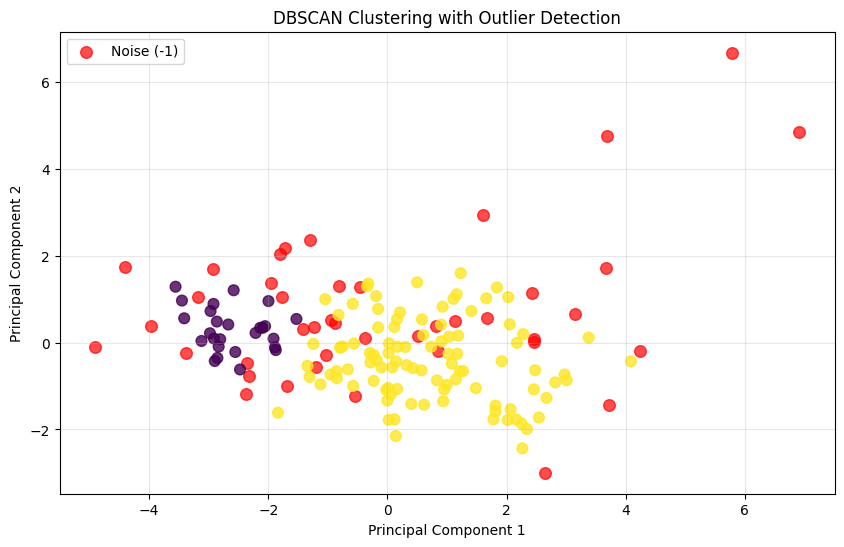

In [311]:
print("DBScan Cluster Visualization")

plt.figure(figsize=(10,6))

noise = df['dbscan_cluster'] == -1

plt.scatter(
    pca_df.loc[noise, 'PC1'],
    pca_df.loc[noise, 'PC2'],
    c='red',
    label='Noise (-1)',
    s=70,
    alpha=0.7)


plt.scatter(
    pca_df.loc[~noise, 'PC1'],
    pca_df.loc[~noise, 'PC2'],
    c=df.loc[~noise, 'dbscan_cluster'],
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.title('DBSCAN Clustering with Outlier Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**DBSCAN Analysis**

DBSCAN was applied as a density-based clustering technique.
Unlike K-Means, DBSCAN automatically identifies dense regions and detects anomalous countries.
Using eps = 1.35 and min_samples = 5:
- Two dense clusters were identified.
- Several countries were classified as outliers.
This helps identify nations with unusual socio-economic conditions that may require special attention.

## 11. Model evaluation

In [312]:
print("KMeans")
kmeans_score = silhouette_score(pca_df,df['KMeans_Cluster'])
print("KMeans Score:", kmeans_score)

KMeans
KMeans Score: 0.32868843897595823


In [313]:
print("DBSCAN")
valid = df['dbscan_cluster'] != -1
labels = df.loc[valid, 'dbscan_cluster']

if labels.nunique() > 1:
    dbscan_score = silhouette_score(pca_df[valid], labels)
    print(f"DBSCAN Score: {dbscan_score:.4f}")
else:
    print("Cannot calculate Silhouette Score: Only one cluster was found.")

DBSCAN
DBSCAN Score: 0.4157


Comparision

In [314]:
print("'Comparison of K-Means and DBSCAN Clustering'")
comparison = pd.DataFrame({
    'Model':['K-Means','DBSCAN'],
    'Silhouette Score':[0.3305,0.4157],
    'Clusters Found':['4','2 + Outliers']
})

comparison

'Comparison of K-Means and DBSCAN Clustering'


,Model,Silhouette Score,Clusters Found
0,K-Means,0.3305,4
1,DBSCAN,0.4157,2 + Outliers


Comparison of K-Means and DBSCAN Clustering


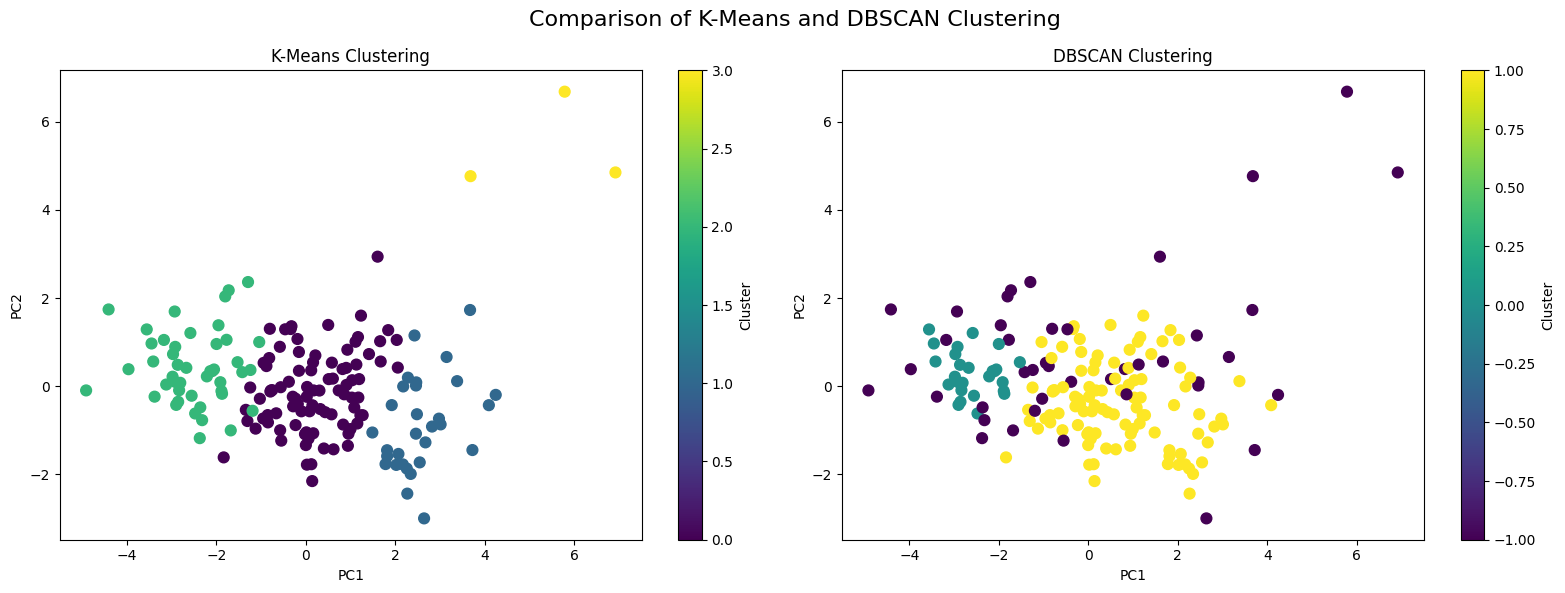

In [325]:
print('Comparison of K-Means and DBSCAN Clustering')

fig, axes = plt.subplots(1, 2,figsize=(16,6))
scatter1 = axes[0].scatter(pca_df['PC1'],pca_df['PC2'],c=df['KMeans_Cluster'],cmap='viridis',s=60)

axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

plt.colorbar(scatter1,ax=axes[0],label='Cluster')
scatter2 = axes[1].scatter(pca_df['PC1'],pca_df['PC2'],c=df['dbscan_cluster'],cmap='viridis',s=60)

axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.colorbar(scatter2,ax=axes[1],label='Cluster')
plt.suptitle('Comparison of K-Means and DBSCAN Clustering',fontsize=16)
plt.tight_layout()
plt.show()

**Model Evaluation**

To assess the quality of clustering, the Silhouette Score was used as the evaluation metric. The Silhouette Score measures how well-separated the clusters are, with values closer to 1 indicating better-defined clusters.

| Model | Silhouette Score |
|---------|---------|
| K-Means | 0.3305 |
| DBSCAN | 0.4157 |

**Analysis**
- K-Means successfully segmented countries into four meaningful development-based groups.
- DBSCAN achieved a higher Silhouette Score, indicating better cluster separation and density-based grouping.
- DBSCAN also identified outlier countries that do not strongly belong to any cluster.
- However, K-Means produced more interpretable and business-friendly clusters that align well with the objective of identifying countries requiring humanitarian aid.

**Conclusion**

Although DBSCAN achieved better numerical performance, K-Means was selected as the primary clustering model because it generated clear and actionable country segments such as:
- Underdeveloped Countries
- Developing Countries
- Developed Countries
- Highly Developed Countries
These segments provide meaningful insights for HELP International to prioritize aid allocation and make data-driven humanitarian decisions.

**Cluster profile**

In [327]:
print('Cluster profile')
cluster_profile[['child_mort',
                 'income',
                 'gdpp',
                 'life_expec',
                 'total_fer']].round(2)

Cluster profile


,child_mort,income,gdpp,life_expec,total_fer
KMeans_Cluster,,,,,
0,21.91,12969.33,6885.53,72.69,2.32
1,4.95,45250.00,43333.33,80.38,1.80
2,95.11,3539.84,1766.71,59.06,5.07
3,4.13,64033.33,57566.67,81.43,1.38


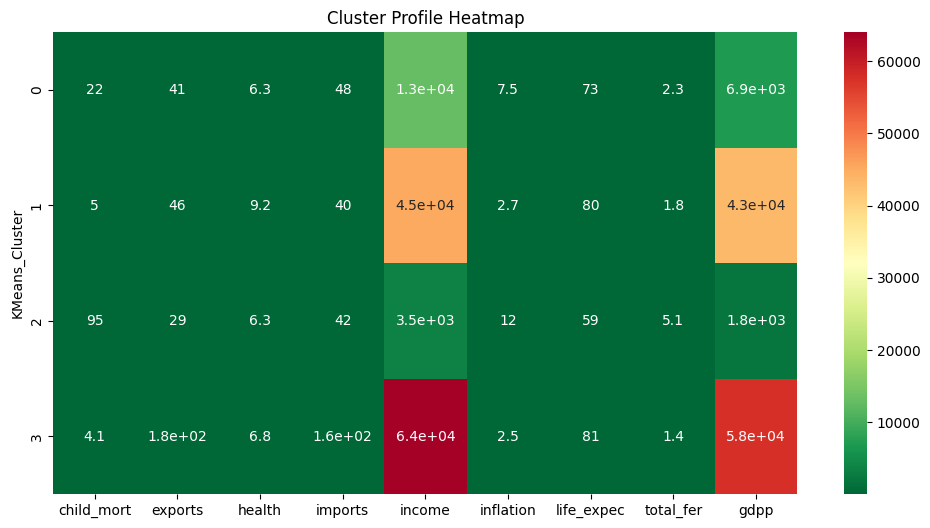

In [328]:

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='RdYlGn_r')

plt.title('Cluster Profile Heatmap')
plt.show()

**Feature Importance**

In [318]:
from sklearn.ensemble import RandomForestClassifier

X = scaled_df
y = df['KMeans_Cluster']
rf = RandomForestClassifier(n_estimators=200,random_state=42)

rf.fit(X, y)
importance = pd.DataFrame({'Feature': scaled_df.columns,'Importance': rf.feature_importances_})
importance.sort_values(by='Importance',ascending=False)

,Feature,Importance
0,child_mort,0.288603
8,gdpp,0.198782
6,life_expec,0.173665
7,total_fer,0.140354
4,income,0.116396
2,health,0.028650
3,imports,0.022299
1,exports,0.019905
5,inflation,0.011346


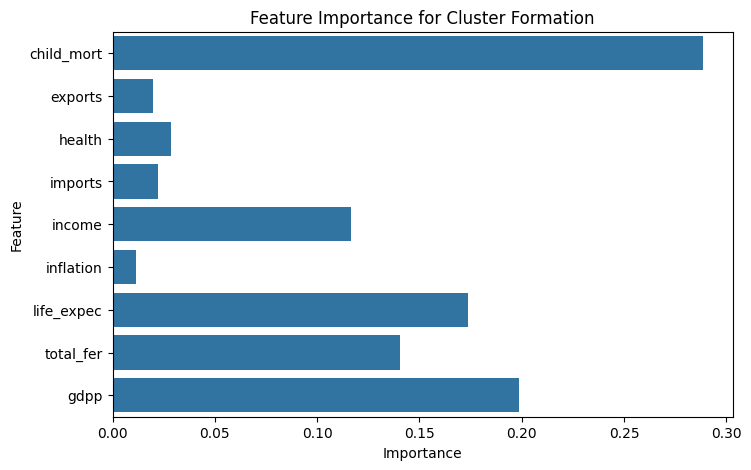

In [319]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance, x='Importance', y='Feature')

plt.title('Feature Importance for Cluster Formation')

plt.show()

## 12. Final Analysis

In [320]:
print("Priority Countries for AID")
priority_countries = df[df['KMeans_Cluster'] == 2]
priority_countries[['country','child_mort','income','gdpp','life_expec']].sort_values(by=['child_mort'],ascending=False)

Priority Countries for AID


,country,child_mort,income,gdpp,life_expec
66,Haiti,208.0,1500,662,32.1
132,Sierra Leone,160.0,1220,399,55.0
32,Chad,150.0,1930,897,56.5
31,Central African Republic,149.0,888,446,47.5
97,Mali,137.0,1870,708,59.5
113,Nigeria,130.0,5150,2330,60.5
112,Niger,123.0,814,348,58.8
3,Angola,119.0,5900,3530,60.1
25,Burkina Faso,116.0,1430,575,57.9
37,"Congo, Dem. Rep.",116.0,609,334,57.5


In [321]:
print("TOP 5 Countries that needed AID")
priority_countries = (df[df['KMeans_Cluster'] == 2].sort_values(by=['child_mort','income'],ascending=[False,True]))
priority_countries[['country','child_mort','gdpp']].head(5)

TOP 5 Countries that needed AID


,country,child_mort,gdpp
66,Haiti,208.0,662
132,Sierra Leone,160.0,399
32,Chad,150.0,897
31,Central African Republic,149.0,446
97,Mali,137.0,708


**Final Conclusion**

In this project, I analyzed socio-economic and health indicators of countries to identify nations that require humanitarian aid.
After performing data preprocessing, feature scaling, PCA, and clustering analysis, countries were grouped into meaningful development-based segments.
Among the identified clusters, Cluster 2 was found to be the most vulnerable due to:

- High child mortality
- Low income
- Low GDP per capita
- Low life expectancy
The analysis suggests that HELP International should prioritize countries belonging to this cluster to maximize the impact of available resources.
This project demonstrates how unsupervised learning can support data-driven humanitarian decision-making and strategic resource allocation.

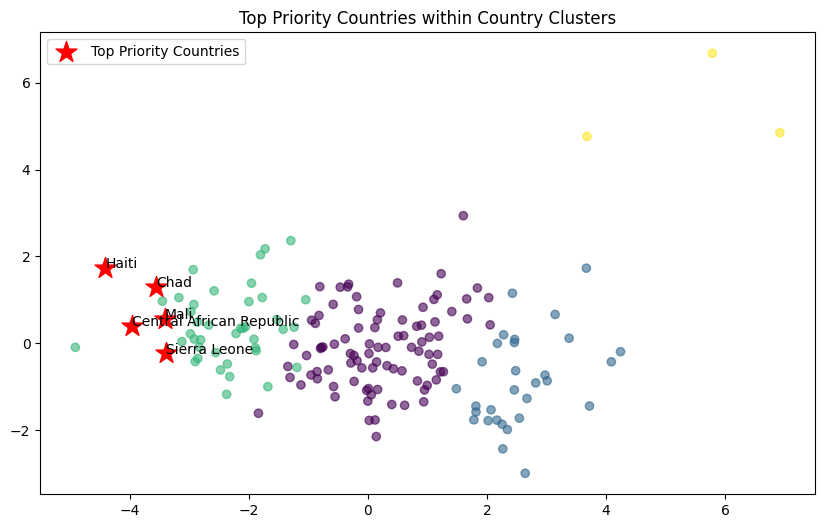

In [322]:
plt.figure(figsize=(10,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    alpha=0.6)

priority_idx = top5.index

plt.scatter(
    pca_df.loc[priority_idx,'PC1'],
    pca_df.loc[priority_idx,'PC2'],
    s=250,
    marker='*',
    color='red',
    label='Top Priority Countries')

for idx in priority_idx:
    plt.annotate(df.loc[idx,'country'],(pca_df.loc[idx,'PC1'],pca_df.loc[idx,'PC2'] ) )

plt.legend()
plt.title( 'Top Priority Countries within Country Clusters')


plt.show()

## 13. Conclusions and CEO Recommendations

**Top 5 Priority Countries for Humanitarian Aid Allocation**
| Rank | Country | Child Mortality (per 1000 births) | GDP per Capita ($) |
|------|---------|-----------------------------------|-------------------|
| 1 | 🇭🇹 Haiti | 208 | 662 |
| 2 | 🇸🇱 Sierra Leone | 160 | 399 |
| 3 | 🇹🇩 Chad | 150 | 897 |
| 4 | 🇨🇫 Central African Republic | 149 | 446 |
| 5 | 🇲🇱 Mali | 137 | 708 |

**Key Observation:** 
These countries exhibit extremely high child mortality rates combined with very low GDP per capita, indicating severe socio-economic challenges and a high need for humanitarian assistance.

**KEY Insights**

***1. Cluster with the Highest Child Mortality***
Cluster 2 has the highest average child mortality rate (~95 deaths per 1000 live births), indicating poor healthcare  and challenging living conditions. This cluster represents the most vulnerable group of countries.

***2. Cluster with the Highest Income and GDP per Capita***
Cluster 3 has the highest average income (~$64K) and GDP per capita (~$58K). Countries in this cluster exhibit strong economic performance, excellent healthcare systems, and the highest living standards.

***3. Most Underdeveloped Cluster***
Cluster 2 appears to be the most underdeveloped cluster because it has the lowest income levels, lowest GDP per capita, lowest life expectancy (~59 years), and the highest fertility and child mortality rates.

***4. Developing vs Developed Nations***
Cluster 0 represents developing countries with moderate economic and health indicators, while Cluster 1 and Cluster 3 represent developed and highly developed nations with strong socio-economic conditions and better quality of life.

***5. Countries That Should Be Prioritized for Aid***
Based on the clustering results, the following countries require the highest priority for humanitarian assistance:

| Country | Child Mortality | GDP per Capita ($) |
|----------|----------|----------|
| 🇭🇹 Haiti | 208 | 662 |
| 🇸🇱 Sierra Leone | 160 | 399 |
| 🇹🇩 Chad | 150 | 897 |
| 🇨🇫 Central African Republic | 149 | 446 |
| 🇲🇱 Mali | 137 | 708 |

These countries belong to the "Needs Immediate Aid" cluster and exhibit severe socio-economic and healthcare challenges. Therefore, HELP International should prioritize these nations for aid allocation to maximize humanitarian impact.


In [323]:
segment_summary = pd.DataFrame({
    'Segment': [
        '🔴 Needs Aid',
        '🟡 Developing',
        '🟢 Developed',
        '🌟 Highly Developed'
    ],
    'Countries': [45 ,89, 30, 3],
    'Clusters' : [2,0,1,2],
    'Key Characteristics': [
        'High child mortality, Low GDP, Low income, Low life expectancy',
        'Moderate socio-economic indicators',
        'High GDP, High income, Low child mortality',
        'Highest GDP, Highest income, Excellent healthcare'
    ]
})

segment_summary.style.hide(axis='index')

Segment,Countries,Clusters,Key Characteristics
🔴 Needs Aid,45,2,"High child mortality, Low GDP, Low income, Low life expectancy"
🟡 Developing,89,0,Moderate socio-economic indicators
🟢 Developed,30,1,"High GDP, High income, Low child mortality"
🌟 Highly Developed,3,2,"Highest GDP, Highest income, Excellent healthcare"


## 14. Strategic Recommendation

HELP International should prioritize funding toward countries in the **Needs Aid Cluster (Cluster 2)**.

These countries exhibit:

- Extremely high child mortality
- Low GDP per capita
- Low income levels
- Poor life expectancy
- High fertility rates

Targeting these nations first will maximize the humanitarian impact of the available $10 million budget.